# Durchführung von Löschwasserberechnungen in PandaPipes (Hydranten werden auf Rohre gesetzt)

Vor der Auseinandersetzung mit diesem Tutorial wird empfohlen, sich erst das Tutorial zu den Hydranten auf Knoten anzugucken. In diesem Tutorial werden nun Hydranten betrachtet, die auf ein Rohr gesetzt werden. Die zwei Möglichkeiten können nicht kombiniert werden. Hier importieren wir deshalb `pandapipes.hydrants.hydrant_on_pipe`.

Achtung: Diese Funktion wurde noch nicht sehr intensiv getestet, es kann also noch zu Fehlern kommen.

In [1]:
import pandapipes as pp
from pandapipes.hydrants.hydrant_on_pipe import *

Wir erstellen dasselbe Netz wie im Tutorial zu den Hydranten auf Knoten.

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


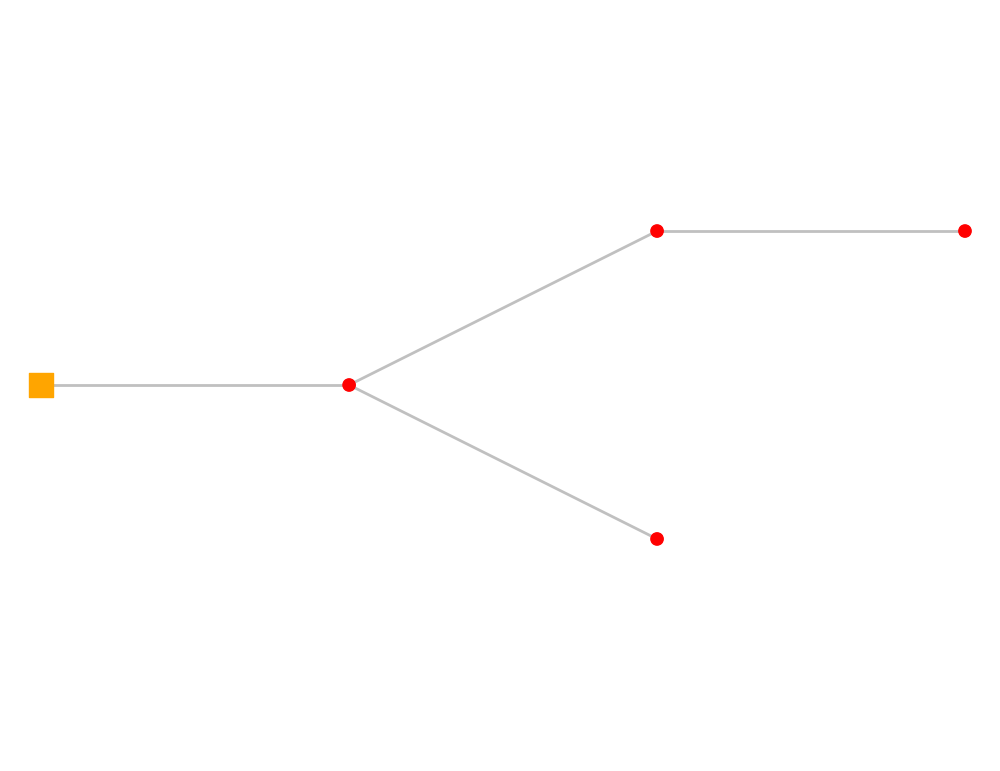

<Axes: >

In [2]:
net = pp.create_empty_network(fluid="water") 

#Erstellen der 5 Knoten
j0 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 1")
j1 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 2") 
j2 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 3")    
j3 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 4") 
j4 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 5") 

#Anbinden eines externen Netzes an den 1-ten und eines Abnehmers an den 5-ten Knoten
ext_grid = pp.create_ext_grid(net, junction=j0, p_bar=3, t_k=293.15, name="Grid Connection")
sink = pp.create_sink(net, junction=j4, mdot_kg_per_s=10, name="Sink")

#Erstellen der Rohre
p0 = pp.create_pipe_from_parameters(net, from_junction=j0, to_junction=j1, length_km=0.1, diameter_m=0.10, name="Pipe 1")
p1 = pp.create_pipe_from_parameters(net, from_junction=j1, to_junction=j2, length_km=0.1, diameter_m=0.10, name="Pipe 2")
p2 = pp.create_pipe_from_parameters(net, from_junction=j1, to_junction=j3, length_km=0.1, diameter_m=0.10, name="Pipe 3")
p3 = pp.create_pipe_from_parameters(net, from_junction=j3, to_junction=j4, length_km=0.01, diameter_m=0.10, name="Pipe 4")

#plotten des Netzes
from pandapipes.plotting import simple_plot
simple_plot(net)


Nun setzen wir einen Hydranten auf das 1. und 2. Rohr. Mit `percentage` können wir angeben auf welcher Strecke zwischen dem Anfangs- und End-Knoten des Rohres der Hydrant liegt. Die Länge, den Druchmesser, die Rauhigkeit und den zusätzliche Verlustfaktor lassen wir wieder bei den Standardwerten. 

Wir erstellen zwei Paare an Hydranten, das zweite Paar liegt bei 100% des Rohrs und damit direkt am Knoten - an den Knoten, an denen auch die Hydranten im anderen Tutorial gelegen haben. Wir erwarten also bei den Hydranten dieselben Ergebnisse.

In [3]:
#Erstellen von zwei Hydranten
create_hydrant(net, pipe=0, percentage=50, name = "Hydrant 1")
create_hydrant(net, pipe=1, percentage=50, name = "Hydrant 2")
create_hydrants(net, pipes = [0,1], percentage=100, name = [ "Hydrant 1.1", "Hydrant 2.1"])
net.hydrant

,name,on_pipe,percentage,length_km,diameter_m,k_mm,loss_coefficient,in_service,connection_pipe_1,connection_pipe_2,hydrant_in_junction,hydrant_out_junction,hydrant_pipe,hydrant_sink
0,Hydrant 1,0,50.0,0.001,0.08,0.1,0.0,False,0,0,0,0,0,0
1,Hydrant 2,1,50.0,0.001,0.08,0.1,0.0,False,0,0,0,0,0,0
2,Hydrant 1.1,0,100.0,0.001,0.08,0.1,0.0,False,0,0,0,0,0,0
3,Hydrant 2.1,1,100.0,0.001,0.08,0.1,0.0,False,0,0,0,0,0,0


So wie im anderen Tutorial haben wir wieder zwei Möglichkeiten das Löschwasser zu berechen. Beachte, dass wie erwartet bei den Knoten die am Ende der Rohre liegen dieselben Ergebnisse wie im anderen Tutorial herauskommen.

In [5]:
#Suchen der maximal möglichen Abnahme für jeden Hydranten
res = run_hydrant_flow_search(net, p_min = 1.5, parallel = False, friction_model = "colebrook")
res

,p_bar,t_k,mdot_kg_per_s,vdot_m3_per_h,min_p_bar,crit_junction,crit_p_bar
0,1.788728,293.15,24.908203,89.680278,1.499917,4.0,1.499917
1,1.500024,293.15,15.380859,55.377730,1.500024,-1.0,1.500024
2,1.707809,293.15,15.638672,56.305966,1.499825,4.0,1.499825
3,1.499730,293.15,13.857422,49.892698,1.499730,-1.0,1.499730


In [4]:
#Suchen der maximalen Abnahme aus einer Liste für jeden Hydranten
res = run_hydrant_flow_list(net, flow_list = [192, 96, 48, 24, 0], flow_unit = "m3/h", p_min = 1.5, parallel = False, friction_model = "colebrook")
res

,p_bar,t_k,mdot_kg_per_s,vdot_m3_per_h,min_p_bar,crit_junction,crit_p_bar
0,2.459588,293.15,13.331736,48.0,2.147553,4.0,2.147553
1,1.752435,293.15,13.331736,48.0,1.717302,4.0,1.717302
2,1.928815,293.15,13.331736,48.0,1.717302,4.0,1.717302
3,1.576056,293.15,13.331736,48.0,1.576056,-1.0,1.576056


Auch können wir wieder einen Hydranten löschen.

In [6]:
delete_hydrant(net, 0)
net.hydrant

,name,on_pipe,percentage,length_km,diameter_m,k_mm,loss_coefficient,in_service,connection_pipe_1,connection_pipe_2,hydrant_in_junction,hydrant_out_junction,hydrant_pipe,hydrant_sink
1,Hydrant 2,1,50.0,0.001,0.08,0.1,0.0,False,0,0,0,0,0,0
2,Hydrant 1.1,0,100.0,0.001,0.08,0.1,0.0,False,0,0,0,0,0,0
3,Hydrant 2.1,1,100.0,0.001,0.08,0.1,0.0,False,0,0,0,0,0,0
